# Funding, basis and positioning workbench

Step 4 of the alpha roadmap. Decisions are made at every UTC hour boundary using
only data available by then. Targets are perp returns over 1, 4, 8 and 24 hours,
entered one minute after the decision. Carry-inclusive P&L subtracts the funding a
position pays (long pays positive funding; short receives it).

| Group | Features |
|---|---|
| baseline | past 1h/4h/24h perp return, 24h realised volatility |
| funding | last settled rate, its 30-day z-score, 1h and 8h premium index, premium change |
| basis | perp–Binance-spot basis (1h), its change versus 24h |
| positioning | open-interest change 1h/24h, OI change × 24h return, top-trader and all-account long/short z-scores, 1h taker buy/sell ratio |

Forecast regressions use the preceding 12 months with a horizon embargo and are
frozen for each test month, January 2023 to May 2026. The three long/short ratio
features are set to 0 when Binance's archive lacks them (most of 2022).

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
RESULTS = REPO / 'alpha-search' / 'reports' / 'funding_positioning_v1'
config = json.loads(
    (REPO / 'alpha-search' / 'configs' / 'funding_positioning_v1.json').read_text()
)
univariate = pl.read_csv(RESULTS / 'univariate_summary.csv')
oos = pl.read_csv(RESULTS / 'oos_summary.csv')
oos_monthly = pl.read_csv(RESULTS / 'oos_monthly.csv')
increments = pl.read_csv(RESULTS / 'oos_increments.csv')
tails = pl.read_csv(RESULTS / 'tail_breakeven.csv')
settlement = pl.read_csv(RESULTS / 'settlement_summary.csv')
coverage = pl.read_csv(RESULTS / 'feature_coverage.csv')

TAKER = 2 * config['costs_bps_per_side']['taker']
MAKER = 2 * config['costs_bps_per_side']['maker']
HORIZONS = config['horizons_hours']
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
INK, MUTED = '#2b2b2b', '#8a8a85'
KEY_MODELS = ['baseline', 'baseline_funding', 'baseline_basis', 'all']
MODEL_COLOUR = dict(zip(KEY_MODELS, SERIES))

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 115,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#e6e6e3',
    'lines.linewidth': 2,
})
pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_float_precision(3)

polars.config.Config

## Manual controls

In [2]:
HORIZON = 24          # 1, 4, 8 or 24 hours
TAIL_FRACTION = 0.2   # 0.01, 0.05 or 0.2

assert HORIZON in HORIZONS
assert TAIL_FRACTION in config['tail_fractions']
display(coverage.transpose(include_header=True, header_name='feature',
                           column_names=['fraction_available']))

feature,fraction_available
str,f64
"""hours""",46704.000
"""ret_1h""",1.000
"""ret_4h""",1.000
"""ret_24h""",1.000
"""rv_24h""",1.000
"""funding_last""",1.000
"""funding_z30d""",1.000
"""premium_1h""",1.000
"""premium_8h""",1.000


## 1. Univariate information by feature and horizon

Mean monthly Spearman IC against the price-only forward return. The left panel is
2021–2022 (the first regression training data) and the right panel is the
2023–May 2026 test period. A feature is credible only if its sign agrees.

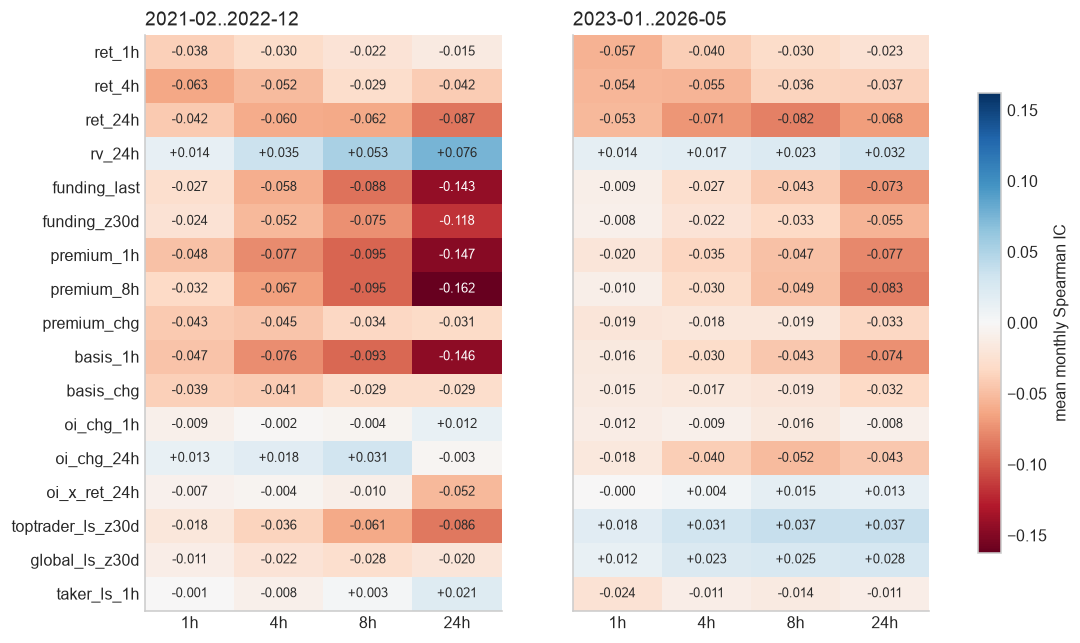

horizon_hours,feature,period,months,mean_spearman_ic,spearman_ic_t,positive_month_fraction
i64,str,str,i64,f64,f64,f64
24,"""ret_1h""","""2023-01..2026-05""",41,-0.023,-4.668,0.171
24,"""ret_4h""","""2023-01..2026-05""",41,-0.037,-4.007,0.195
24,"""premium_1h""","""2023-01..2026-05""",41,-0.077,-3.643,0.268
24,"""basis_1h""","""2023-01..2026-05""",41,-0.074,-3.518,0.268
24,"""funding_last""","""2023-01..2026-05""",41,-0.073,-3.456,0.317
24,"""premium_8h""","""2023-01..2026-05""",41,-0.083,-3.435,0.293
24,"""ret_24h""","""2023-01..2026-05""",41,-0.068,-3.343,0.268
24,"""premium_chg""","""2023-01..2026-05""",41,-0.033,-2.940,0.341
24,"""basis_chg""","""2023-01..2026-05""",41,-0.032,-2.843,0.341


In [3]:
features = [f for group in config['feature_groups'].values() for f in group]
fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)
limit = univariate['mean_spearman_ic'].abs().max()
for ax, period in zip(axes, ['2021-02..2022-12', '2023-01..2026-05']):
    view = univariate.filter(pl.col('period') == period)
    grid = np.array([
        [view.filter((pl.col('feature') == f) & (pl.col('horizon_hours') == h))
         ['mean_spearman_ic'][0] for h in HORIZONS]
        for f in features
    ])
    image = ax.imshow(grid, cmap='RdBu', vmin=-limit, vmax=limit, aspect='auto')
    ax.set_xticks(range(len(HORIZONS)), [f'{h}h' for h in HORIZONS])
    ax.set_yticks(range(len(features)), features)
    ax.grid(False)
    for i in range(len(features)):
        for j in range(len(HORIZONS)):
            ax.text(j, i, f'{grid[i, j]:+.3f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(grid[i, j]) > 0.6 * limit else INK)
    ax.set_title(period, loc='left')
fig.colorbar(image, ax=axes, label='mean monthly Spearman IC', shrink=0.8)
plt.show()
univariate.filter(
    (pl.col('horizon_hours') == HORIZON) & (pl.col('period') == '2023-01..2026-05')
).sort('spearman_ic_t')

## 2. Out-of-sample forecast comparison

Mean monthly OOS Spearman IC of each frozen model's forecast, by horizon.

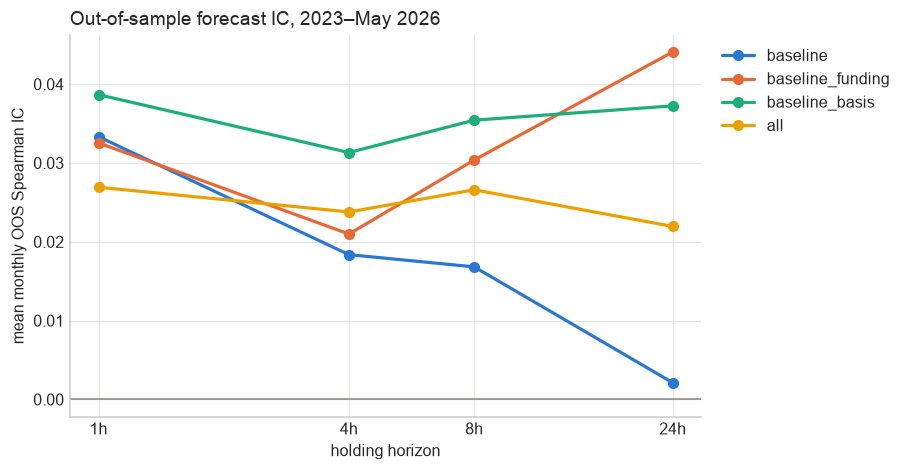

horizon_hours,model,months,mean_spearman_ic,spearman_ic_t,positive_month_fraction
i64,str,i64,f64,f64,f64
24,"""baseline_funding""",41,0.044,2.535,0.659
24,"""funding_only""",41,0.042,2.084,0.659
24,"""basis_only""",41,0.042,3.126,0.756
24,"""baseline_basis""",41,0.037,2.180,0.610
24,"""all""",41,0.022,1.063,0.537
24,"""baseline""",41,0.002,0.097,0.585
24,"""baseline_positioning""",41,-0.002,-0.106,0.512
24,"""positioning_only""",41,-0.022,-0.920,0.415


horizon_hours,candidate,mean_ic_gain_over_baseline,gain_t,better_month_fraction
i64,str,f64,f64,f64
1,"""all""",-0.006,-0.780,0.463
1,"""baseline_basis""",0.005,1.049,0.537
1,"""baseline_funding""",-0.001,-0.121,0.512
1,"""baseline_positioning""",-0.003,-0.436,0.561
4,"""all""",0.005,0.405,0.561
4,"""baseline_basis""",0.013,1.904,0.707
4,"""baseline_funding""",0.003,0.256,0.488
4,"""baseline_positioning""",0.007,0.591,0.512
8,"""all""",0.010,0.488,0.512


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for model in KEY_MODELS:
    series = oos.filter(pl.col('model') == model).sort('horizon_hours')
    ax.plot(series['horizon_hours'], series['mean_spearman_ic'], marker='o',
            markersize=6, color=MODEL_COLOUR[model], label=model)
ax.set_xscale('log')
ax.set_xticks(HORIZONS, [f'{h}h' for h in HORIZONS])
ax.minorticks_off()
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xlabel('holding horizon')
ax.set_ylabel('mean monthly OOS Spearman IC')
ax.set_title('Out-of-sample forecast IC, 2023–May 2026', loc='left')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()
display(oos.filter(pl.col('horizon_hours') == HORIZON))
increments

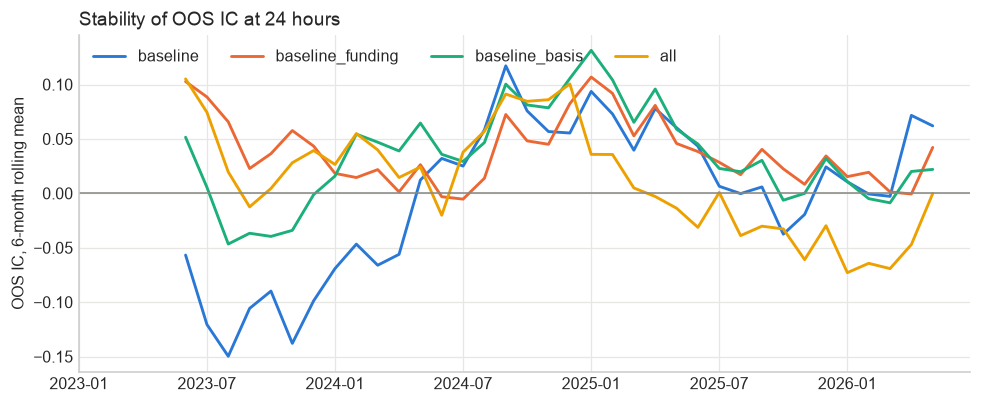

In [5]:
monthly = oos_monthly.filter(pl.col('horizon_hours') == HORIZON)
fig, ax = plt.subplots(figsize=(10, 3.8))
for model in KEY_MODELS:
    series = monthly.filter(pl.col('model') == model).sort('test_month')
    ax.plot(range(series.height), series['spearman_ic'].rolling_mean(6),
            color=MODEL_COLOUR[model], label=model, linewidth=1.8)
ticks = series['test_month'].to_list()
ax.set_xticks(range(0, len(ticks), 6), ticks[::6])
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_ylabel('OOS IC, 6-month rolling mean')
ax.set_title(f'Stability of OOS IC at {HORIZON} hours', loc='left')
ax.legend(frameon=False, ncol=4, loc='upper left')
plt.show()

## 3. Costed tails with funding carry

Trades are taken only when the frozen forecast's magnitude exceeds the training
quantile for the tail fraction. `mean_carry_edge_bps` includes the funding the
position pays or receives. The best-10-day share and the edge on all other days
test whether the result depends on a few stress days. Round-trip costs: taker 10
bps, maker 4 bps (base tier). At 8–24 hours, passive (maker) execution is
realistic because entry is not urgent.

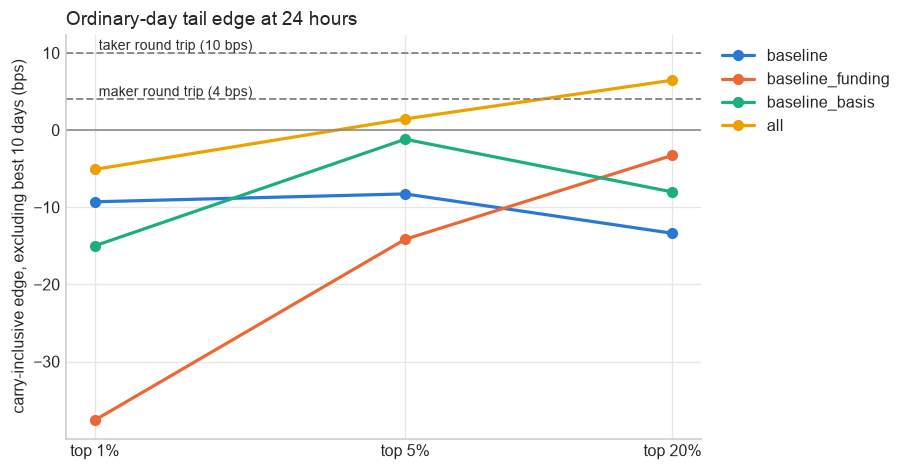

model,trades_per_day,mean_price_edge_bps,mean_carry_edge_bps,daily_block_t,net_taker_bps,best_10_day_share,edge_excluding_best_10_days_bps,edge_2023_bps,edge_2024_bps,edge_2025_bps,edge_2026_bps
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""all""",9.697,19.887,20.397,2.644,10.397,0.691,6.469,35.517,13.593,3.249,15.542
"""baseline_positioning""",8.876,18.740,18.550,2.081,8.550,0.942,1.099,31.705,59.209,-15.031,-3.134
"""funding_only""",8.189,12.910,13.674,2.076,3.674,0.919,1.128,27.239,-0.809,25.119,6.024
"""positioning_only""",9.292,11.410,11.503,-0.087,1.503,1.689,-8.165,32.769,54.190,-54.256,0.854
"""basis_only""",6.442,8.860,9.977,1.389,-0.023,0.982,0.188,10.875,2.797,32.308,0.776
"""baseline_funding""",9.257,8.044,8.602,2.151,-1.398,1.370,-3.263,23.198,-15.349,13.113,13.118
"""baseline_basis""",8.099,4.228,4.949,2.480,-5.051,2.571,-8.018,2.926,-2.277,11.449,13.608
"""baseline""",8.280,2.531,1.558,1.170,-8.442,9.310,-13.373,-28.222,16.000,0.042,10.937


In [6]:
year_columns = sorted(c for c in tails.columns if c.startswith('edge_20'))
view = tails.filter(pl.col('horizon_hours') == HORIZON)
fig, ax = plt.subplots(figsize=(8, 4.2))
for model in KEY_MODELS:
    series = view.filter(pl.col('model') == model).sort('tail_fraction')
    ax.plot(series['tail_fraction'] * 100, series['edge_excluding_best_10_days_bps'],
            marker='o', markersize=6, color=MODEL_COLOUR[model], label=model)
for level, label in [(TAKER, 'taker round trip'), (MAKER, 'maker round trip')]:
    ax.axhline(level, color=MUTED, linestyle='--', linewidth=1.2)
    ax.text(1, level, f' {label} ({level:g} bps)', va='bottom', ha='left', fontsize=9,
            color=INK)
ax.set_xscale('log')
fractions = config['tail_fractions']
ax.set_xticks([f * 100 for f in fractions], [f'top {f:.0%}' for f in fractions])
ax.minorticks_off()
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_ylabel('carry-inclusive edge, excluding best 10 days (bps)')
ax.set_title(f'Ordinary-day tail edge at {HORIZON} hours', loc='left')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()
view.filter(pl.col('tail_fraction') == TAIL_FRACTION).select(
    'model', 'trades_per_day', 'mean_price_edge_bps', 'mean_carry_edge_bps',
    'daily_block_t', 'net_taker_bps', 'best_10_day_share',
    'edge_excluding_best_10_days_bps', *year_columns
).sort('mean_carry_edge_bps', descending=True)

## 4. Around funding settlements

Returns in the hour before and after each 00:00/08:00/16:00 UTC settlement,
grouped by the premium over the preceding seven hours (terciles cut on 2021–2022).

In [7]:
settlement

period,predicted_funding_tercile,settlements,mean_pre_hour_return_bps,pre_hour_return_bps_day_t,mean_post_hour_return_bps,post_hour_return_bps_day_t
str,str,i64,f64,f64,f64,f64
"""2021-02..2022-12""","""1 low premium""",698,3.931,0.969,-1.209,-0.067
"""2021-02..2022-12""","""2 middle""",697,-0.544,0.165,-1.605,-1.105
"""2021-02..2022-12""","""3 high premium""",699,-1.299,-0.415,3.550,-0.008
"""2023-01..2026-05""","""1 low premium""",1718,0.845,1.040,2.355,1.967
"""2023-01..2026-05""","""2 middle""",1310,-1.972,-1.179,-1.088,-1.149
"""2023-01..2026-05""","""3 high premium""",713,-3.458,-1.375,1.124,0.784


## Reading

See `alpha-search/reports/funding-positioning-v1-initial-results.md`.